In [1]:
import datetime as dt
import os
import sys

import cartopy.crs as ccrs
import cmocean as cmo
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

# import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import (
    domains,
    get_nn_lon_lat_index,
    haversine,
    hp_mods,
    hp_to_latlon,
    sim_colors,
    sim_labels,
    sim_specific_labels,
    sims,
    sims_new,
    um_sims,
)

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)
print("hooray; running")

hooray; running


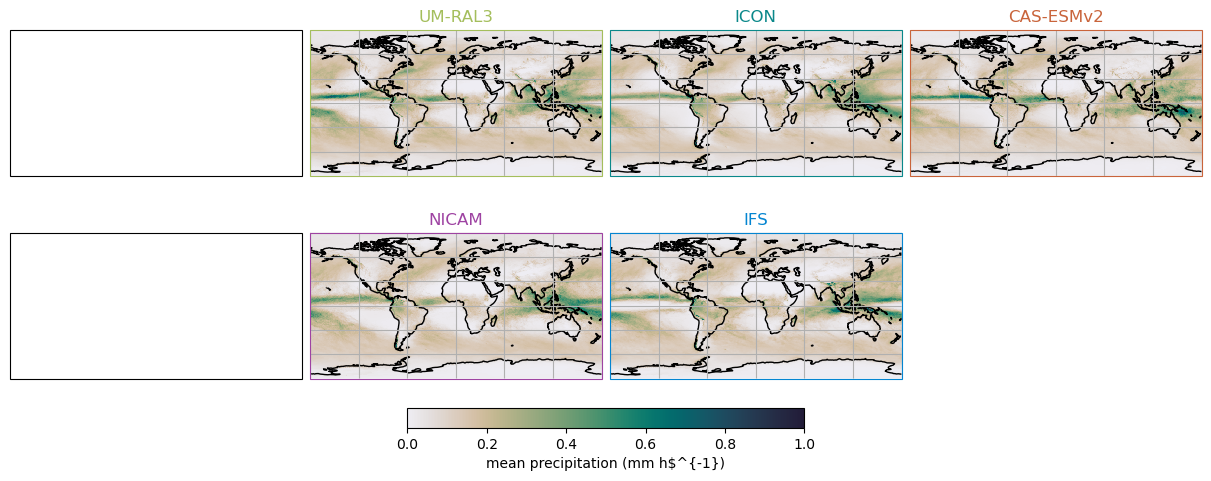

In [13]:
def plot_rainfall(
    ax, sim, extent=None, zoom=7, period_ix=0, thresholds="", color="k", title=None
):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    if title == None:
        title = sim
    if sim.lower() == "chirps":
        da = xr.open_dataarray(f"monthlymeans/chirps_dwtps.nc")

    else:
        da = xr.open_dataarray(f"monthlymeans/{sim}_global_zoom_{zoom}.nc")

    da = da.sel(time=slice("2020-03", "2021-02")).mean(dim="time") * 3600
    if "ifs" in sim:
        da/=3.6

    m = da.plot(cmap=cmo.cm.rain, vmin=0, vmax=1, ax=ax, add_colorbar=False)

    ax.coastlines()
    ax.gridlines()
    ax.set_title(title, color=color)
    ax.tick_params(color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
    return ax, m


figsize = (9, 6)
figsize = (12, 5)


projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    4,
    # height_ratios=[1] * len(zooms) + [0.1],
    figsize=figsize,
    subplot_kw={"projection": projection},
    layout="constrained",
)

# ax, m = plot_rainfall(
#     axes[0, 0], "IR_IMERG", [left, right, bottom, top], zoom=9, title="IMERG"
# )

# ax, m = plot_rainfall(
#     axes[1, 0],
#     "CHIRPS",
# )

for sim_ix, sim in enumerate(sims_new):
    ax, m = plot_rainfall(
        axes[int(np.floor(sim_ix / 3)), (sim_ix % 3) + 1],
        sim,
        color=sim_colors[sim],
        title=sim_labels[sim],
    )


fig.colorbar(
    m,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.07,
    shrink=0.7,
    label="mean precipitation (mm h$^{-1})",
)
axes[1, 3].set_frame_on(False)

In [8]:
xr.open_dataarray(
    "/home/users/franmorr/hk26/hackathon-monsoons/precip/monthlymeans/um_glm_n2560_RAL3p3_tuned_hk26_global_zoom_7.nc"
)

<xarray.DataArray 'pr' (time: 15, latitude: 393, longitude: 786)> Size: 19MB
[4633470 values with dtype=float32]
Coordinates:
    crs        int64 8B ...
    cell       (latitude, longitude) int64 2MB ...
    lat        (latitude, longitude) float64 2MB ...
    lon        (latitude, longitude) float64 2MB ...
  * latitude   (latitude) float64 3kB -90.0 -89.54 -89.08 ... 89.08 89.54 90.0
  * longitude  (longitude) float64 6kB -179.8 -179.3 -178.9 ... 179.3 179.8
  * time       (time) datetime64[ns] 120B 2020-01-31 2020-02-29 ... 2021-03-31
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [  1   4 203]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['stratiform_rainfall_flux', 'stratiform_snowfall_flux']
    notes:          Combined rain and snow. Hourly mean - time index shifted ...
    grid_mapping:   crs